<a href="https://colab.research.google.com/github/pvt-16/Coursework/blob/main10/Dissertation_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Admin work

## Import packages

In [ ]:
import os
import glob
import datetime
from datetime import datetime, timedelta

import pandas as pd
import numpy as np

#Visualization
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import statsmodels.api as sm
from scipy import stats # as stats - for tests

# import sm.stats as sms
# from sm.stats import descriptivestats as smsd

## Import data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
local_path = 'G:/My Drive/Labs/Dissertation/'  # 'drive/MyDrive/Labs/Dissertation/'
dataset_path = 'Datasets'
full_path = local_path + dataset_path

In [ ]:
all_datasets = os.listdir(local_path + dataset_path)
print(all_datasets)

['Dataset 1', 'Dataset 2', 'Dataset 3', 'Dataset 4']


In [ ]:
# for dataset_folder in all_datasets:
#   local_folder_path = local_path + dataset_folder
#   if os.path.isdir(local_path):
#     inner_dataset = os.listdir(path = local_folder_path)
#     for dataset in inner_dataset:
#       os.path.join(local_folder_path, dataset)
#       if os.path.isdir()


In [ ]:
#glob.glob(full_path + '/*/*/*')

In [ ]:
dataset_name ='/Dataset 3'
folder_name ='/Normalized1Hz'
dataset = ""

stress_label_file_name = 'Experimental Schedule'
timings_file_name = 'Timings'

timestamp_format =  '%Y-%m-%d %H-%M'
primary_key = "time_s"

original_cols = ['ACT', 'EDA', 'HR', 'IBI', 'TEMP']

In [ ]:
%%time

combined_dataset_1 = pd.DataFrame()
new_col_names = [primary_key]

for name in glob.glob(full_path + dataset_name):
  if os.path.isdir(name):
    files = os.listdir(name) #glob.glob(name + '/*')
    directories = [f for f in files if os.path.isdir(name +"/"+ f)]
    
    # 1. LABEL FILE
    label_file = list(filter( lambda f: stress_label_file_name in f, files))[0]
    if label_file.endswith("xls") or label_file.endswith("xlsx"):
      experimental_sched = pd.read_excel(name +"/"+ label_file)
    else:
      experimental_sched = pd.read_csv(name +"/"+ label_file)
    
    #remove unnecessary cols
    extra_cols = list(filter(lambda col: "Unnamed" in str(col), experimental_sched.columns))

    #remove na cols
    #TODO: Automatically filters out the non-timeslot rows. Check against some test cases
    experimental_sched = experimental_sched.drop(extra_cols, axis = 1).dropna()
    experimental_sched = experimental_sched.reset_index(drop=True)

    # 2. DATA FILES
    dataset_count = 0
    for timestamp_name in directories:   #timestamp data

      # 2.1 Get Timings file
      time_file_name = f'{name}/{timestamp_name}/{timings_file_name}'
      timings_file = pd.read_csv(time_file_name)
      

      # 2.2 Get columns data
      file_name = f'{name}/{timestamp_name}/{folder_name}' #name + "/" + timestamp_name + folder_name
      #print(file_name) #drive/MyDrive/Labs/Dissertation/Datasets/Dataset 3/2019-08-14 12-30/Normalized1Hz

      #if os.path.isdir(file_name):
      #features = glob.glob(file_name)
      variable_file_names = os.listdir(file_name)
      variable_file_names = sorted(list(filter(lambda x: x.startswith("e4") and x.endswith("csv"), variable_file_names)))

      # read all column data as one dataframe
      combined_sub_dataset = pd.DataFrame()
      # for col in variable_file_names: # cols - features - EDA, ACT etc.
      #   metric_name = col.split(".csv")[0].replace("e4_","")  # file is in the list of cols we want
      #   col_data = pd.read_csv(file_name + "/" + col)

      #   if combined_sub_dataset.empty:
      #     combined_sub_dataset = col_data
      #   else: # dataset is not empty
      #     # columns need filling
      #     if primary_key in col_data.columns:
      #       combined_sub_dataset = combined_sub_dataset.merge(col_data, how="left", on=primary_key) #merge on primary key else leave it
      #     else:
      #       continue  #TODO: cols that don't have P_KEY
            
      #   #creating new column names
      #   if dataset_count == 0 and (primary_key in col_data.columns):
      #     for col_name in list(col_data.columns):
      #       if col_name != primary_key:
      #         new_col_names.append(metric_name + "_" + col_name.strip())        
        
      #   # row needs filling
      #   # append all datasets to main dataset
      #   combined_sub_dataset.columns = new_col_names


      #   if dataset_count ==0:
      #     combined_dataset_1 = combined_sub_dataset.copy()
      #   else:
      #     combined_dataset_1 = combined_dataset_1.append(combined_sub_dataset.copy(), ignore_index= True)
        
      #   dataset_count +=1
      #   print("combo", combined_dataset_1.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'G:/My Drive/Labs/Dissertation/Datasets/Dataset 3/2019-08-12 10-00/Timings'

In [ ]:
combined_dataset_1.isna().sum()/combined_dataset_1.shape[0] *100

time_s          0.000000
ACT_act_g       0.000000
EDA_uS          0.006746
EDA_SCL_uS      0.006746
EDA_SCR_uS      0.006746
HR_bpm          0.296836
IBI_HR_bpm      4.035620
IBI_LERP_s      4.035620
IBI_RMSSD_ms    4.667071
TEMP_C          0.025636
dtype: float64

In [ ]:
experimental_sched

,Time Slot,Participant ID,1,2,3,4,5,6,7,8,9,10,11,12
0,2019-08-12 10:00:00,CL1,O,A,O,B,O,C,O,C,O,B,O,A
1,2019-08-12 12:30:00,ER1,O,B,O,C,O,A,O,A,O,C,O,B
2,2019-08-13 10:00:00,BO1,O,A,O,C,O,B,O,B,O,C,O,A
3,2019-08-13 12:30:00,VV1,O,B,O,A,O,C,O,C,O,A,O,B
4,2019-08-13 15:00:00,OI1,O,C,O,B,O,A,O,A,O,B,O,C
5,2019-08-14 10:00:00,CF1,O,A,O,B,O,C,O,C,O,B,O,A
6,2019-08-14 12:30:00,AJ1,O,B,O,C,O,A,O,A,O,C,O,B
7,2019-08-14 15:00:00,CB1,O,C,O,A,O,B,O,B,O,A,O,C
8,2019-08-15 10:00:00,WZ1,O,A,O,C,O,B,O,B,O,C,O,A
9,2019-08-15 12:30:00,AL1,O,B,O,A,O,C,O,C,O,A,O,B


In [ ]:
timings_file = pd.read_excel(name +"/"+ label_file)

#### labelling code


In [ ]:
# add extra columns
#for timestamp_name in directories:   #timestamp data

timestamp = datetime.strptime(timestamp_name, timestamp_format)
experimental_sched.columns = experimental_sched.columns.map(str)
#print(selected_row)
selected_row = experimental_sched[experimental_sched['Time Slot'] == timestamp].values[0].tolist()[2:]
#selected_row.columns = selected_row.columns.map(str)

duration_row = experimental_sched[experimental_sched['Time Slot'] == 'Duration'].values[0].tolist()[2:]

brief_duration = 5
duration_row.insert(0, brief_duration)
selected_row.insert(0, 'Brief')
#print(duration_row)
# class labels
timeblocks_arr = np.array(timestamp)

start_time = timestamp; 
end_time= 0

for idx, stress_dur in enumerate(duration_row):
  end_time = start_time + timedelta(minutes= stress_dur)
  print(start_time, stress_dur, end_time, selected_row[idx])
  start_time = end_time

    # demographic augmentation

2019-08-20 15:00:00 5 2019-08-20 15:05:00 Brief
2019-08-20 15:05:00 3 2019-08-20 15:08:00 O
2019-08-20 15:08:00 5 2019-08-20 15:13:00 A
2019-08-20 15:13:00 3 2019-08-20 15:16:00 O
2019-08-20 15:16:00 5 2019-08-20 15:21:00 B
2019-08-20 15:21:00 3 2019-08-20 15:24:00 O
2019-08-20 15:24:00 5 2019-08-20 15:29:00 C
2019-08-20 15:29:00 3 2019-08-20 15:32:00 O
2019-08-20 15:32:00 5 2019-08-20 15:37:00 C
2019-08-20 15:37:00 3 2019-08-20 15:40:00 O
2019-08-20 15:40:00 5 2019-08-20 15:45:00 B
2019-08-20 15:45:00 3 2019-08-20 15:48:00 O
2019-08-20 15:48:00 5 2019-08-20 15:53:00 A


In [ ]:
#duration_row.iloc[0,]

In [ ]:
selected_row.iloc[stress_dur,0]

AttributeError: ignored

#### old code for columns

In [ ]:
# #from re import split
# var_names = dataset[1]
# #.split(".csv")[0].split("_")[1] 

# #TODO: replace with regex
# #var_names = list(filter(lambda x: x.split(".csv")[0].replace("e4_","") in original_cols, var_names))
# print(var_names)

In [ ]:
# combined_dataset_1 = pd.DataFrame()
# primary_key = "time_s"
# file_path = dataset[0]
# new_col_names = [primary_key]

# for col in var_names:
#   if col.endswith(".csv"):
#     #print(col)
#     metric_name = col.split(".csv")[0].replace("e4_","")
#     col_data = pd.read_csv(file_path + "/" + col)
#     if combined_dataset_1.empty:
#       combined_dataset_1 = col_data
#     else:
#       if primary_key in col_data.columns:
#         combined_dataset_1 = combined_dataset_1.merge(col_data, how="left", on=primary_key)

#     if primary_key in col_data.columns:
#       for col_name in list(col_data.columns):
#         if col_name != primary_key:
#           new_col_names.append(metric_name + "_" + col_name.strip())
#     print(combined_dataset_1.shape)

In [ ]:
new_col_names

In [ ]:
combined_dataset_1.columns = new_col_names

## Common functions

In [ ]:
def standardization(data):
    return (data-data.mean())/data.std()

def normalization(data):
    return (data-data.min())/(data.max()-data.min())

# EDA

In [ ]:
combined_dataset_1.tail(50)

,time_s,ACT_act_g,EDA_uS,EDA_SCL_uS,EDA_SCR_uS,HR_bpm,IBI_HR_bpm,IBI_LERP_s,IBI_RMSSD_ms,TEMP_C
74065,20/08/2019 16:19:37.000,-0.002,-1.176,-1.070,-0.231,-1.137,-0.680,0.428,-0.680,-0.228
74066,20/08/2019 16:19:38.000,-0.074,-1.231,-1.069,-0.348,-1.137,-0.685,0.350,-0.687,-0.263
74067,20/08/2019 16:19:39.000,0.061,-1.310,-1.068,-0.512,-1.137,-0.702,0.348,-0.693,-0.332
74068,20/08/2019 16:19:40.000,-0.049,-1.338,-1.068,-0.572,-1.137,-0.724,0.157,-0.702,-0.228
74069,20/08/2019 16:19:41.000,0.044,-1.351,-1.067,-0.599,-1.137,-0.788,0.564,-0.686,-0.263
74070,20/08/2019 16:19:42.000,0.013,-1.375,-1.067,-0.648,-1.137,-0.789,0.505,-0.684,-0.263
74071,20/08/2019 16:19:43.000,0.007,-1.394,-1.068,-0.686,-1.137,-0.807,0.492,-0.682,-0.263
74072,20/08/2019 16:19:44.000,-0.160,-1.349,-1.069,-0.592,-1.137,-0.840,0.704,-0.677,-0.263
74073,20/08/2019 16:19:45.000,0.079,-1.276,-1.070,-0.439,-1.140,-0.794,0.694,-0.674,-0.263
74074,20/08/2019 16:19:46.000,-0.030,-1.210,-1.071,-0.298,-1.141,NaN,NaN,-0.688,-0.263


In [ ]:
# check null columns
combined_dataset_1.isna().sum() /combined_dataset_1.shape[0] *100

time_s          0.000000
ACT_act_g       0.000000
EDA_uS          0.006746
EDA_SCL_uS      0.006746
EDA_SCR_uS      0.006746
HR_bpm          0.296836
IBI_HR_bpm      4.035620
IBI_LERP_s      4.035620
IBI_RMSSD_ms    4.667071
TEMP_C          0.025636
dtype: float64

In [ ]:
combined_dataset_1.describe()

,ACT_act_g,EDA_uS,EDA_SCL_uS,EDA_SCR_uS,HR_bpm,IBI_HR_bpm,IBI_LERP_s,IBI_RMSSD_ms,TEMP_C
count,74115.000000,7.411000e+04,74110.000000,74110.000000,73895.000000,7.112400e+04,71124.000000,70656.000000,74096.000000
mean,-0.000005,6.881662e-07,-0.000001,0.000002,-0.000001,-4.217985e-07,-0.000001,0.000001,-0.000007
std,1.000008,1.000008e+00,1.000007,1.000006,1.000008,1.000007e+00,1.000003,1.000010,1.000005
min,-0.711000,-6.773000e+00,-12.526000,-0.971000,-5.239000,-4.630000e+00,-8.417000,-2.757000,-21.346000
25%,-0.374000,-7.230000e-01,-0.660000,-0.345000,-0.587000,-6.400000e-01,-0.622000,-0.650000,-0.702000
50%,-0.262000,-1.650000e-01,-0.071000,-0.230000,-0.144000,-1.000000e-01,0.009000,-0.233000,0.095000
75%,-0.093000,5.520000e-01,0.547000,-0.047000,0.448000,5.410000e-01,0.625000,0.379000,0.707000
max,36.261000,2.694100e+01,6.375000,32.138000,12.632000,7.612000e+00,7.531000,9.715000,4.312000


In [ ]:
sm.stats.Describe(combined_dataset_1)

In [ ]:
combined_dataset_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74115 entries, 0 to 74114
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time_s        74115 non-null  object 
 1   ACT_act_g     74115 non-null  float64
 2   EDA_uS        74110 non-null  float64
 3   EDA_SCL_uS    74110 non-null  float64
 4   EDA_SCR_uS    74110 non-null  float64
 5   HR_bpm        73895 non-null  float64
 6   IBI_HR_bpm    71124 non-null  float64
 7   IBI_LERP_s    71124 non-null  float64
 8   IBI_RMSSD_ms  70656 non-null  float64
 9   TEMP_C        74096 non-null  float64
dtypes: float64(9), object(1)
memory usage: 5.7+ MB


In [ ]:
combined_dataset_1.corr().style.background_gradient(cmap='coolwarm')

,ACT_act_g,EDA_uS,EDA_SCL_uS,EDA_SCR_uS,HR_bpm,IBI_HR_bpm,IBI_LERP_s,IBI_RMSSD_ms,TEMP_C
ACT_act_g,1.000000,-0.006971,-0.159197,0.278572,0.018610,0.052195,-0.019841,0.033901,-0.047558
EDA_uS,-0.006971,1.000000,0.791767,0.281173,0.180017,0.159034,-0.135588,-0.020118,0.294694
EDA_SCL_uS,-0.159197,0.791767,1.000000,-0.261325,0.138315,0.125501,-0.111274,-0.027810,0.279544
EDA_SCR_uS,0.278572,0.281173,-0.261325,1.000000,0.090224,0.085207,-0.070240,0.012140,0.052459
HR_bpm,0.018610,0.180017,0.138315,0.090224,1.000000,0.268750,-0.240244,0.030601,0.053252
IBI_HR_bpm,0.052195,0.159034,0.125501,0.085207,0.268750,1.000000,-0.825861,-0.086117,0.061415
IBI_LERP_s,-0.019841,-0.135588,-0.111274,-0.070240,-0.240244,-0.825861,1.000000,0.094051,-0.064179
IBI_RMSSD_ms,0.033901,-0.020118,-0.027810,0.012140,0.030601,-0.086117,0.094051,1.000000,-0.061796
TEMP_C,-0.047558,0.294694,0.279544,0.052459,0.053252,0.061415,-0.064179,-0.061796,1.000000


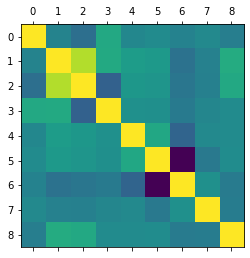

In [ ]:
plt.matshow(combined_dataset_1.corr())

## EDA Visualization

CPU times: user 30.7 s, sys: 609 ms, total: 31.3 s
Wall time: 30.9 s


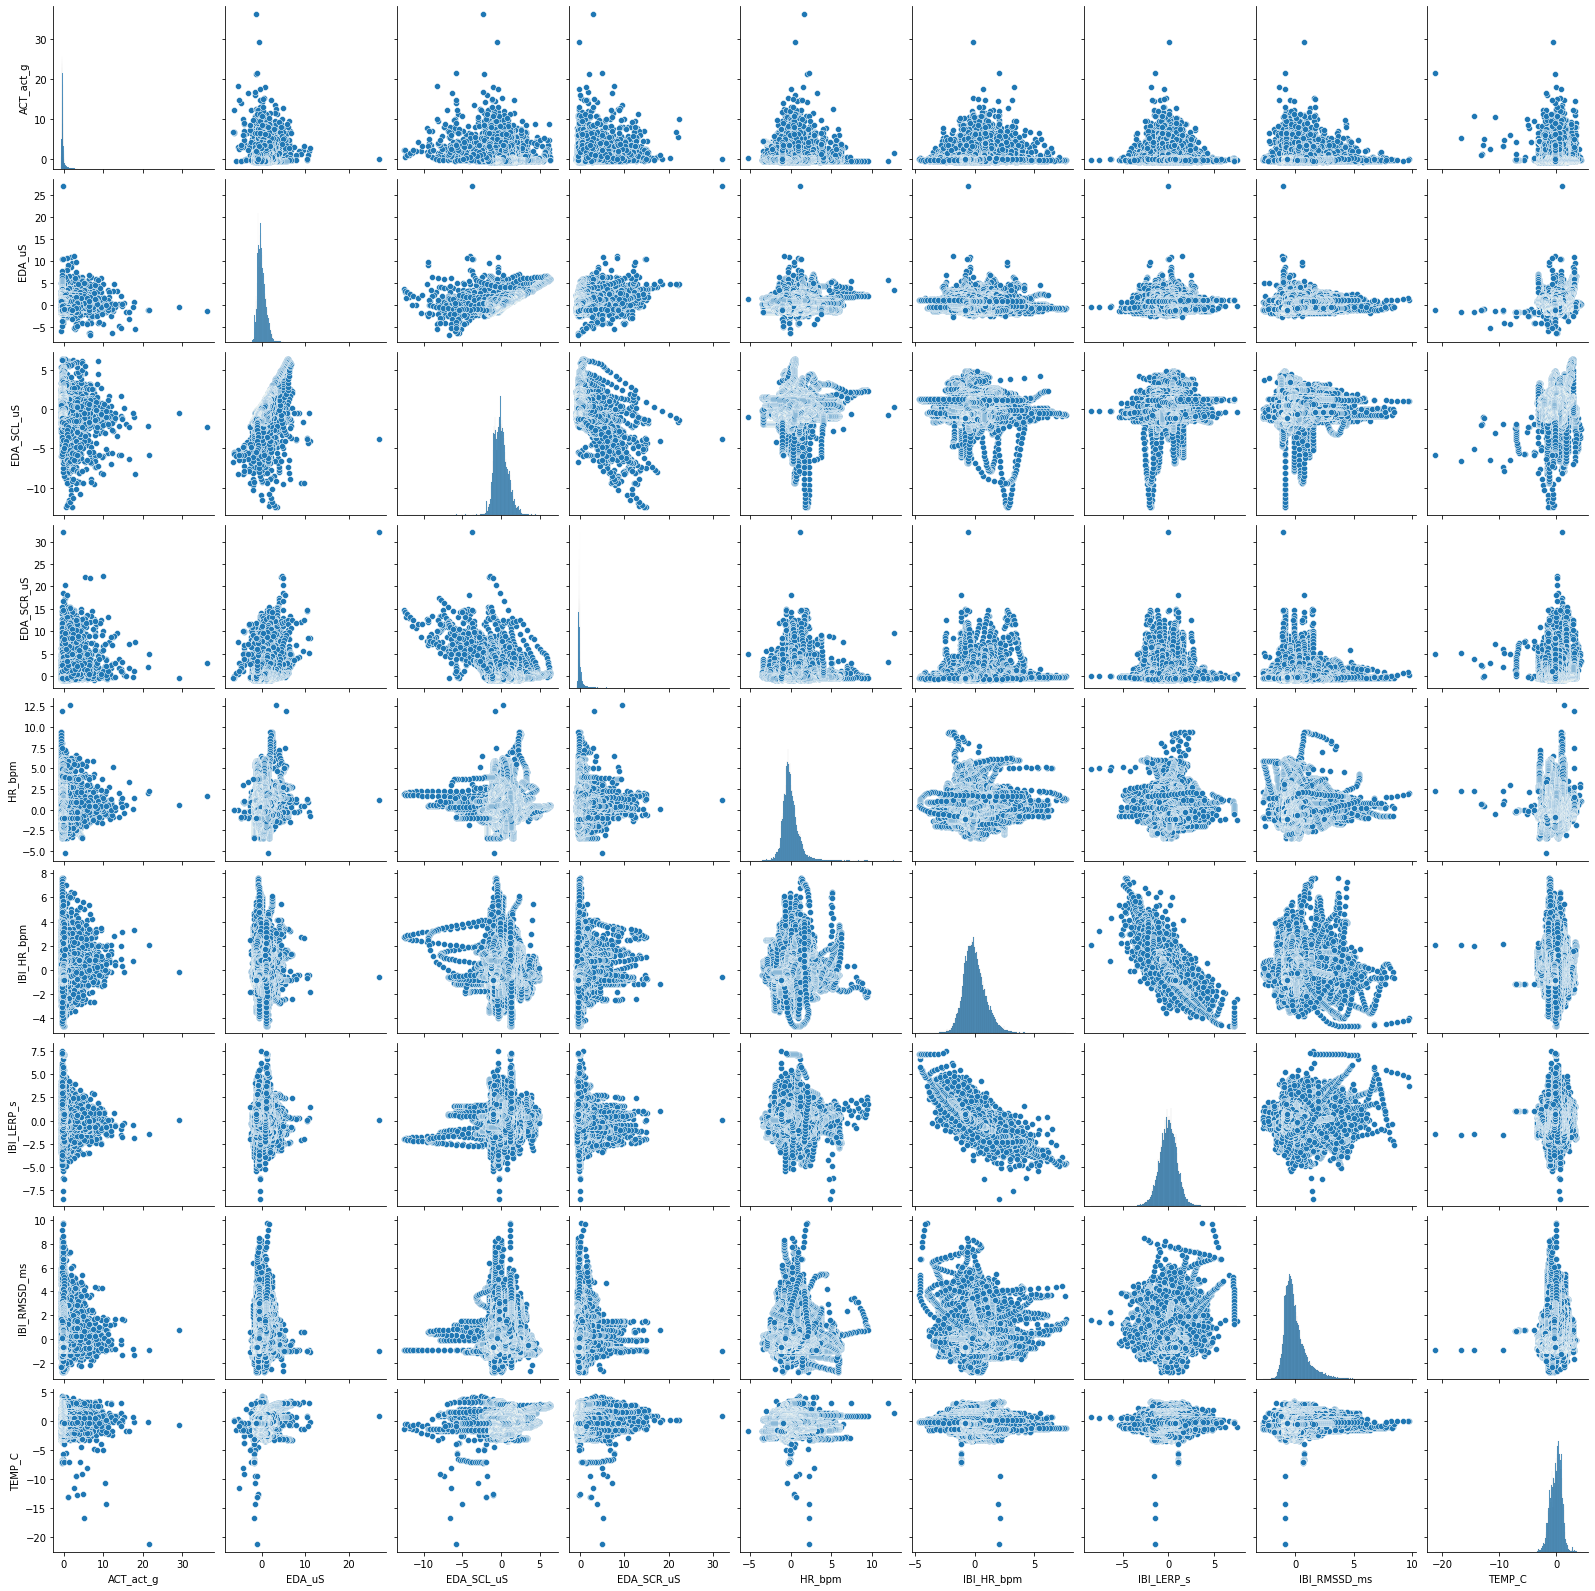

In [ ]:
%%time
sns.pairplot(combined_dataset_1)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


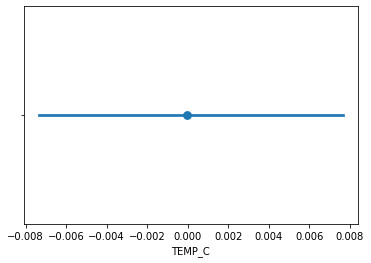

In [ ]:
combined_dataset_1.columns

Index(['time_s', 'ACT_act_g', 'EDA_uS', 'EDA_SCL_uS', 'EDA_SCR_uS', 'HR_bpm',
       'IBI_HR_bpm', 'IBI_LERP_s', 'IBI_RMSSD_ms', 'TEMP_C'],
      dtype='object')

In [ ]:
#pd.DataFrame.plot(combined_dataset_1,combined_dataset_1['time_s'],combined_dataset_1['TEMP_C']                )

TypeError: ignored

In [ ]:
top_20 = combined_dataset_1.head(20)

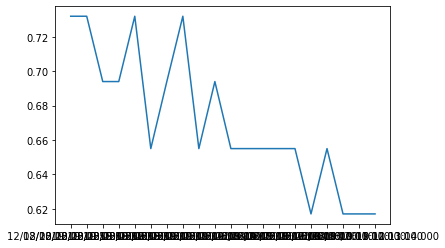

In [ ]:
plt.plot(top_20['time_s'],top_20['TEMP_C'])
plt.show()

# Feature Engg.

# Clustering

# Classification